## Lab Practice Ensemble learning 1.2:  BAGGING  | Machine Learning II
#### ESU  Jan-2025
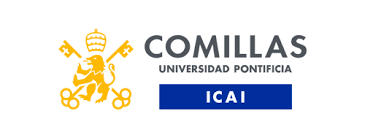

LEARNING OBJECTIVES
- How to apply bagging in classification trees
- Deep understanding of the variability created by boostrap in the ensemble of trees


---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.inspection import permutation_importance

from sklearn.ensemble import BaggingClassifier
#from sklearn.ensemble import BaggingRegressor

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_classification_ml2 as ucml2

---
## 1. Classification problem

#### 1.1 Load the dataset

In [2]:
# Load file with the dataset
df = pd.read_csv('simDataTriangle.dat', sep = "\t")
print('Dataframe:')
print(df.head())

# Convert output variable to categorical
df.Y = df.Y.astype('category')

Dataframe:
         X1        X2        X3        X4        X5        X6    Y
0 -0.416315  5.704369 -0.520502  5.624744 -0.567509  5.657103  OUT
1 -0.052473  9.467372 -0.308278  9.518659 -0.028233  9.271118  OUT
2 -0.552123  7.329100 -0.563368  7.373105 -0.851291  7.175183  OUT
3  0.290578  7.804284  0.248642  7.461996 -0.038654  7.557059  INS
4  0.116236  7.472282  0.154657  7.231131  0.154816  7.462239  INS


#### 1.2 Exploratory analysis


Info variables:
               X1          X2          X3          X4          X5          X6
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000
mean     0.484328    6.115594    0.488827    6.124073    0.487352    6.121143
std      0.606122    2.678621    0.633653    2.686707    0.632867    2.687277
min     -0.597901    0.010610   -0.906872   -0.182318   -0.973871   -0.090703
25%     -0.045126    4.507014   -0.009401    4.432009   -0.004716    4.415462
50%      0.475767    6.614707    0.508919    6.619594    0.479645    6.572260
75%      1.023133    8.265262    0.998416    8.306398    0.990994    8.278550
max      1.499564    9.976869    1.982567   10.558648    1.924748   10.294785


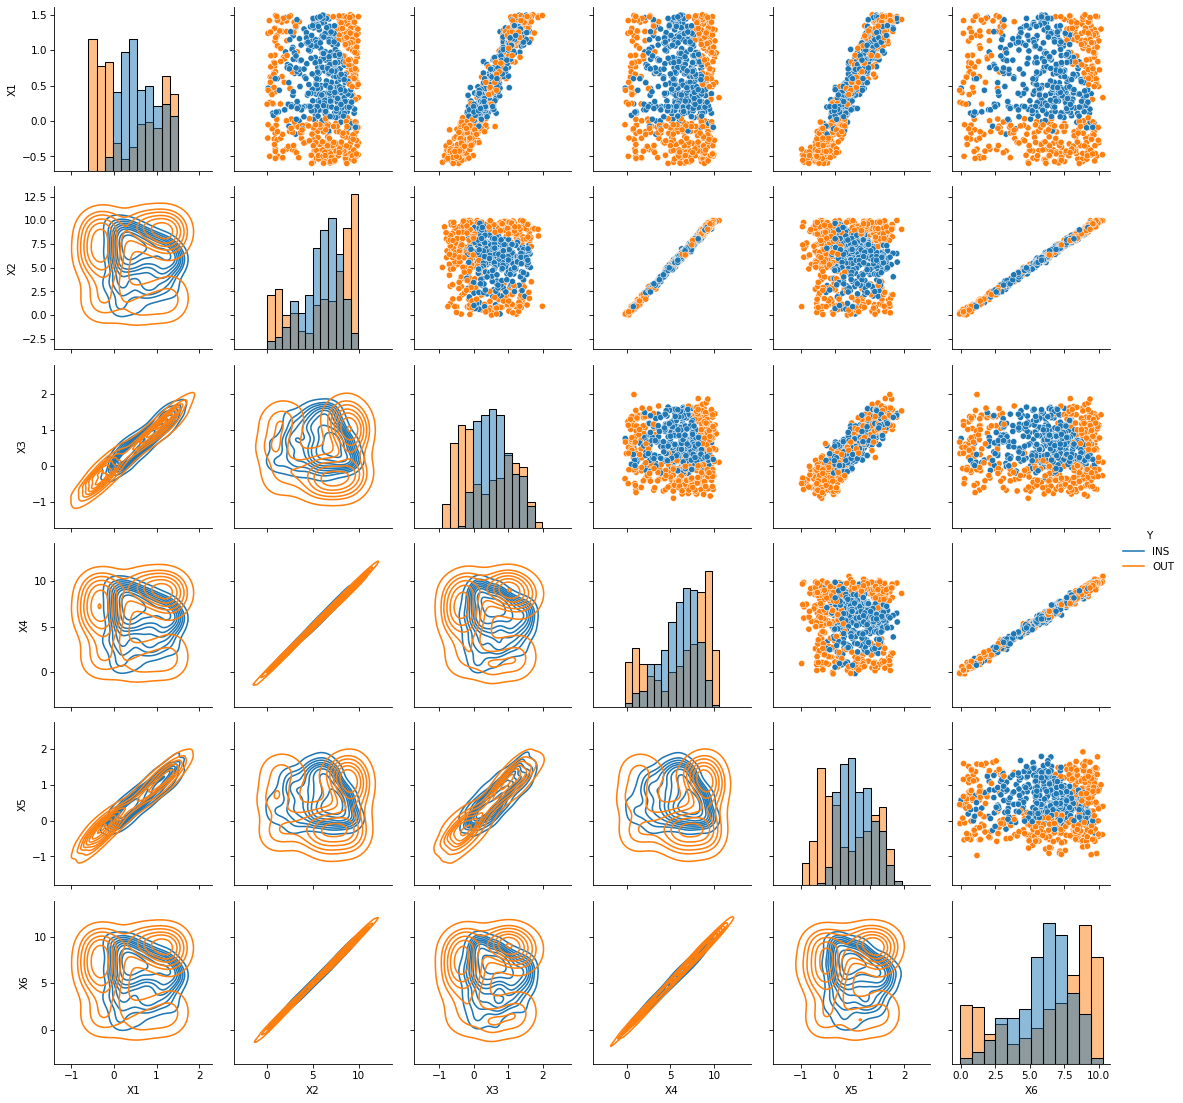

In [3]:
# Basic exploratory analysis

print('\nInfo variables:')
print(df.describe())

g = sns.PairGrid(df, hue="Y")
g.map_diag(sns.histplot)
#g.map_offdiag(sns.scatterplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.add_legend()

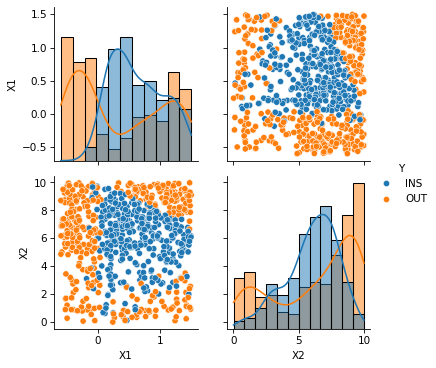

In [4]:
# Focus on interesting variables
g = sns.PairGrid(df, vars=["X1", "X2"], hue="Y")
g.map_diag(sns.histplot, kde=True)
g.map_offdiag(sns.scatterplot)
g.add_legend()

#### 1.3 Split the dataset in TR and TS

In [6]:
# Define input and output matrices
INPUTS = ['X1','X2','X3','X4','X5','X6']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

### 1.4 Fit **single classification tree** (for comparison)

In [7]:
## Inputs of the model
INPUTS_DT = INPUTS

# grid in min_impurity x min_samples_leaf x min_samples_split
param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005), # Minimum entropy to decrease in each split
         'DT__min_samples_leaf': np.arange(1,10,1), # Minimum number of obs in a terminal node
         'DT__min_samples_split':  np.arange(2,10,1)} # Minimum number of obs in node to keep cutting

# Si min_samples_leaf=5, entonces cada hoja final del árbol debe contener al menos 5 observaciones.
# Si se encuentra una posible división que dejaría una hoja con 4 muestras, el árbol rechazará la división.

# Si min_samples_split=5, el árbol solo dividirá un nodo si hay al menos 5 observaciones en él.
# Si un nodo tiene solo 4 muestras, aunque pudiera mejorar la impureza con una división, no se divide.

# param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005)} # Minimum entropy to decrease in each split

pipe = Pipeline(steps=[('DT', DecisionTreeClassifier(criterion='gini',  # impurity measure
                                                     random_state=150))]) # For replication
                                                     
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined.

# Importante el refit=True, para que se entrene el mejor modelo con todo el conjunto de entrenamiento.

nFolds = 10
tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds, # Number of Folds 
                       refit=True) # (default) the best model is finally refitted using the whole training set ** Importante!!!!!
tree_fit.fit(X_train[INPUTS_DT], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('DT',
                                        DecisionTreeClassifier(random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045]),
                         'DT__min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'DT__min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='accuracy')

In [8]:
# Show the best grid parameter combination found by CV
tree_fit.best_estimator_['DT'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': np.float64(0.0),
 'min_samples_leaf': np.int64(3),
 'min_samples_split': np.int64(8),
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 150,
 'splitter': 'best'}

##### 1.4.1 Plot the single classification tree

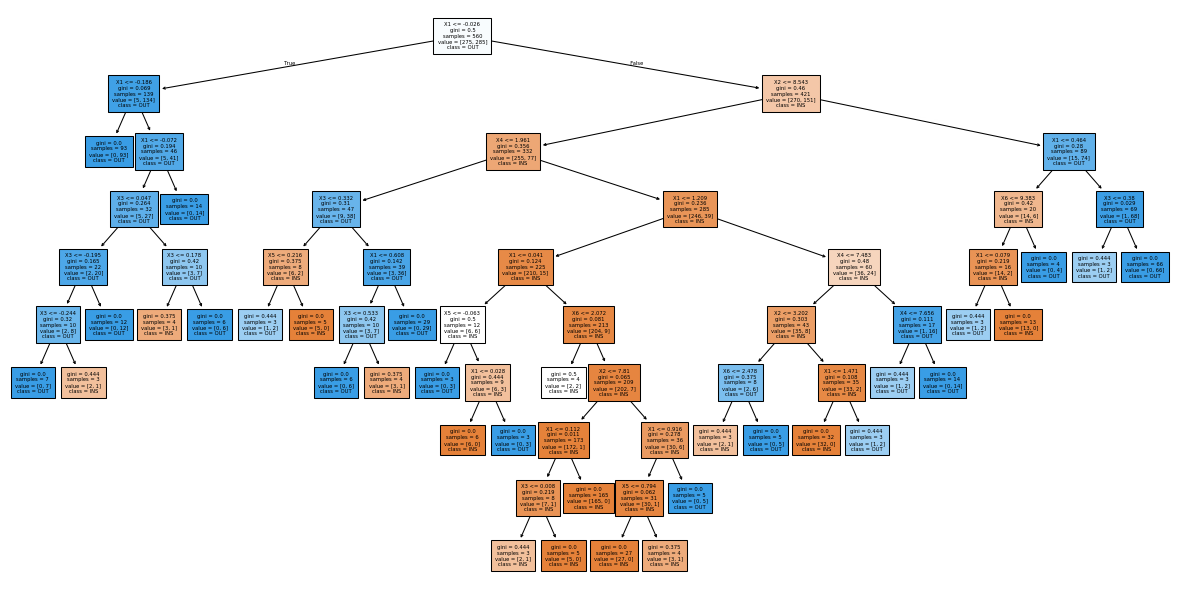

In [9]:
## Plot the decision tree model (use figsize and fontsize for getting the best view)
plt.figure(figsize=(20, 10))
plot_tree(tree_fit.best_estimator_['DT'],
          feature_names= INPUTS_DT,
          class_names= [str(s) for s in y_train.unique()],
          fontsize=5, filled=True)
plt.show()

In [10]:
## Imprimimos el árbol como un esquema
# Easy reading of the tree
print(export_text(tree_fit.best_estimator_['DT'], feature_names= INPUTS_DT))

|--- X1 <= -0.03
|   |--- X1 <= -0.19
|   |   |--- class: OUT
|   |--- X1 >  -0.19
|   |   |--- X1 <= -0.07
|   |   |   |--- X3 <= 0.05
|   |   |   |   |--- X3 <= -0.20
|   |   |   |   |   |--- X3 <= -0.24
|   |   |   |   |   |   |--- class: OUT
|   |   |   |   |   |--- X3 >  -0.24
|   |   |   |   |   |   |--- class: INS
|   |   |   |   |--- X3 >  -0.20
|   |   |   |   |   |--- class: OUT
|   |   |   |--- X3 >  0.05
|   |   |   |   |--- X3 <= 0.18
|   |   |   |   |   |--- class: INS
|   |   |   |   |--- X3 >  0.18
|   |   |   |   |   |--- class: OUT
|   |   |--- X1 >  -0.07
|   |   |   |--- class: OUT
|--- X1 >  -0.03
|   |--- X2 <= 8.54
|   |   |--- X4 <= 1.96
|   |   |   |--- X3 <= 0.33
|   |   |   |   |--- X5 <= 0.22
|   |   |   |   |   |--- class: OUT
|   |   |   |   |--- X5 >  0.22
|   |   |   |   |   |--- class: INS
|   |   |   |--- X3 >  0.33
|   |   |   |   |--- X1 <= 0.61
|   |   |   |   |   |--- X3 <= 0.53
|   |   |   |   |   |   |--- class: OUT
|   |   |   |   |   |--- X3 > 

##### 1.4.2 Compute errors of the single classification tree

In [11]:
# model predictions in training (TR) and test (TS) sets
clf = tree_fit.best_estimator_['DT']
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()

# main metrics
# training accuracy
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
# test accuracy
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                         TR        TS
Accuracy           0.976786  0.885714
Balanced accuracy  0.976874  0.885691

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  270    5
      OUT    8  277

Accuracy: 0.98
No Information Rate: 0.5
Kappa: 0.95
Mcnemar's Test P-Value: 0.58
Sensitivity: 0.97
Specificity: 0.98
Precision: 0.97
Recall: 0.98
Prevalence: 0.51
Detection Rate: 0.49
Detection prevalence: 0.5
Balanced accuracy: 0.98
F1 Score: 0.98
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   61    8
      OUT    8   63

Accuracy: 0.89
No Information Rate: 0.5
Kappa: 0.77
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.89
Specificity: 0.88
Precision: 0.88
Recall: 0.88
Prevalence: 0.51
Detection Rate: 0.45
Detection prevalence: 0.51
Balanced accuracy: 0.89
F1 Score: 0.88
Positive label: INS


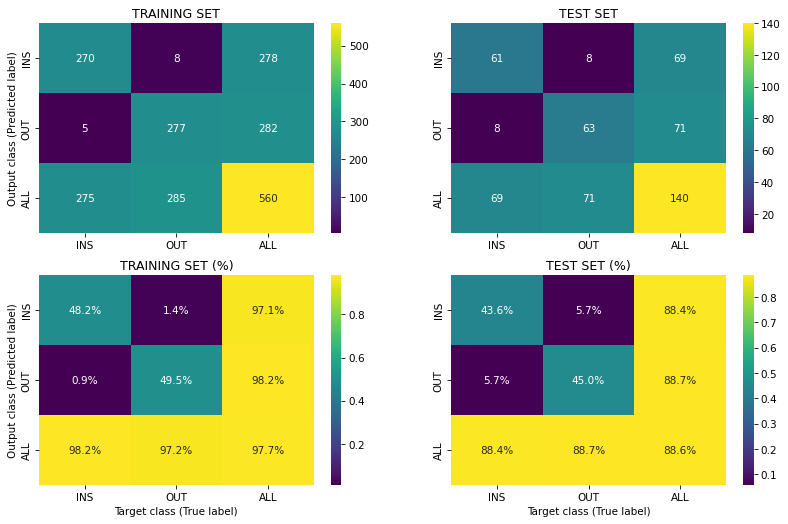

In [12]:
ucml2.plot_expanded_confusion_matrix(clf, X_train, y_train, X_test, y_test)

Confusion in TRAINING SET


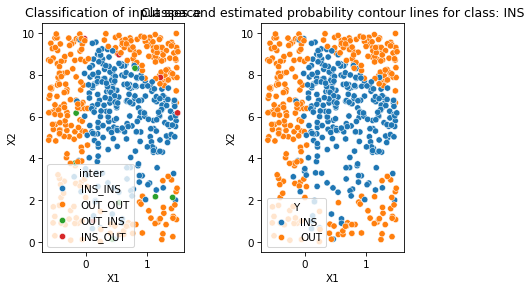

Confusion in TEST SET


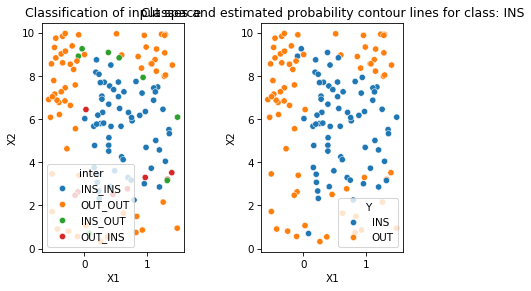

In [13]:
### Plot classification in a 2 dimensional space
print('Confusion in TRAINING SET')
uml1.plot2DClass(X_train[INPUTS_DT], y_train, clf, 'X1', 'X2', 'INS', 50)
print('Confusion in TEST SET')
uml1.plot2DClass(X_test[INPUTS_DT], y_test, clf, 'X1', 'X2', 'INS', 50) 

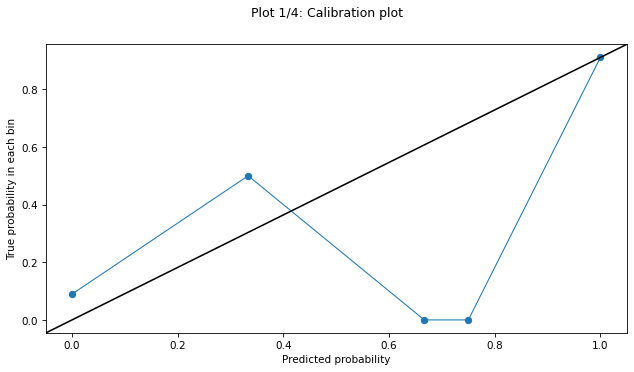

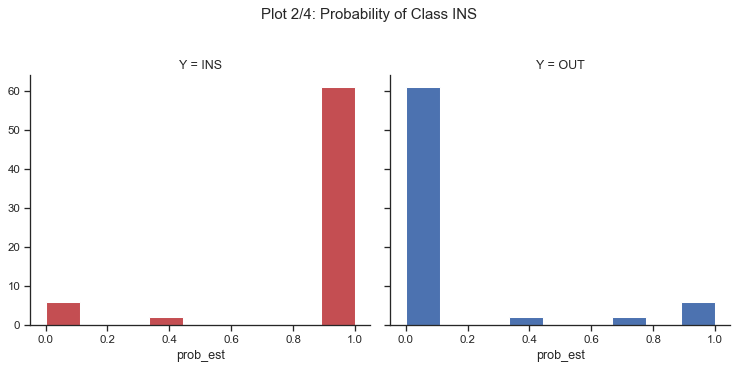

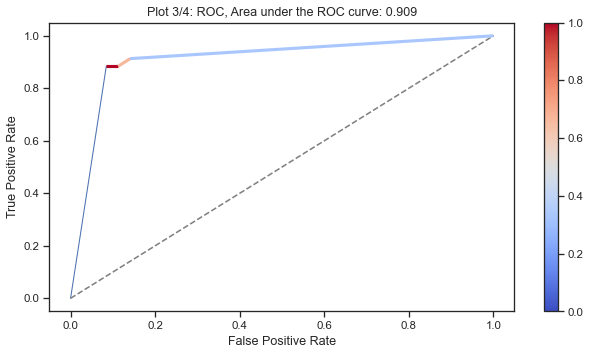

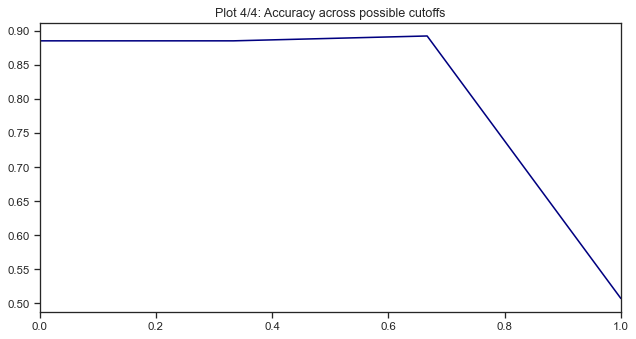

In [14]:
uml1.plotClassPerformance(y_test, clf.predict_proba(X_test[INPUTS_DT]), selClass='INS')

##### 1.4.3 Importances of the inputs in the single tree

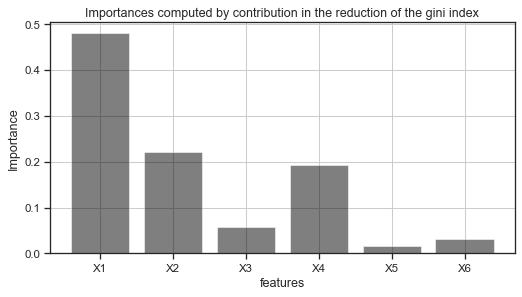

In [15]:
## Plot the variable importance of each feature
plt.figure(figsize=(8, 4))
bar_width = 0.35
plt.bar(INPUTS_DT, tree_fit.best_estimator_['DT'].feature_importances_, color='black', alpha=0.5)
plt.xlabel('features')
plt.ylabel('Importance')
plt.title('Importances computed by contribution in the reduction of the gini index')
plt.grid()
plt.show()
## Miramos que corte ha prodcudoo cada variable y cuanto antes se hayan utilizado, más relevante es.

### 1.5 Fit Bagged tree

##### 1.5.1 First straightforward version (without optim hyperparameters)

In [17]:
## Bagging sin gridsearch


number_estimators = 50

# Que tipo de modelo vamos a usar para hacer bagging. En nuestro caso, un árbol de decisión.
base_estimator =  Pipeline(steps=[('DT', 
                                    DecisionTreeClassifier( criterion='gini',  # impurity measure
                                                            min_samples_split=2, # Minimum number of obs in node to keep cutting
                                                            min_samples_leaf=1, # Minimum number of obs in a terminal node
                                                            random_state=999))]) # For replication

# Definimos el modelo de bagging.
bag_class_estim = BaggingClassifier(estimator=base_estimator,
                                    n_estimators=number_estimators, #Número de muestras bootstraps
                                    random_state=0)
                     
# fit the bagged trees
INPUTS_BT = INPUTS                 
bag_class_estim.fit(X_train[INPUTS_BT], y_train)

BaggingClassifier(estimator=Pipeline(steps=[('DT',
                                             DecisionTreeClassifier(random_state=999))]),
                  n_estimators=50, random_state=0)

In [18]:
# model predictions in training (TR) and test (TS) sets
clf = bag_class_estim
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()

# main metrics
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                         TR        TS
Accuracy           0.998214  0.921429
Balanced accuracy  0.998182  0.921515

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  274    1
      OUT    0  285

Accuracy: 1.0
No Information Rate: 0.5
Kappa: 1.0
Mcnemar's Test P-Value: 1.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0
Recall: 1.0
Prevalence: 0.51
Detection Rate: 0.51
Detection prevalence: 0.51
Balanced accuracy: 1.0
F1 Score: 1.0
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   64    5
      OUT    6   65

Accuracy: 0.92
No Information Rate: 0.5
Kappa: 0.84
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.92
Specificity: 0.93
Precision: 0.91
Recall: 0.93
Prevalence: 0.51
Detection Rate: 0.46
Detection prevalence: 0.5
Balanced accuracy: 0.92
F1 Score: 0.92
Positive label: INS


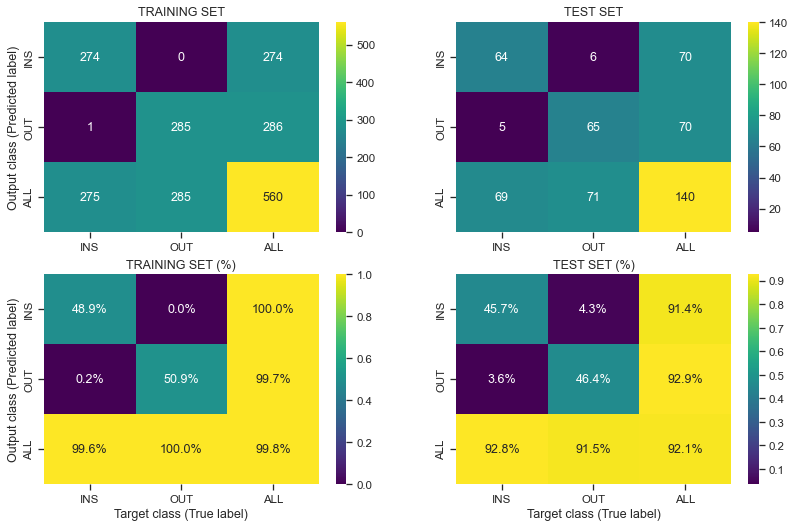

In [19]:
# Hemos mejorado ligeramente con respecto al árbol único, pues antes en train teniamos 8;5 y en test 8;8 y ahora tenemos 0;1 y 6;5
ucml2.plot_expanded_confusion_matrix(clf, X_train, y_train, X_test, y_test)

##### 1.5.2 Feature importance evaluation in bagging using "Permutation Importance"

The permutation importance of a feature is calculated as follows:
- First, a baseline metric, defined by scoring, is evaluated on a (potentially different) dataset defined by the X. 
- Next, a feature column from the validation set is permuted and the metric is evaluated again. 
- The permutation importance is defined to be the difference between the baseline metric and metric from permutating the feature column.

For further reading see L. Breiman, “Random Forests”, Machine Learning, 45(1), 5-32, 2001.

**Ejemplo Intuitivo de Permutation Importance**

Imagina que quieres predecir el precio de una casa y tienes dos características en tu modelo:

1.	Tamaño (m²) → Característica importante para el precio.
    
2.	Color de la puerta → Característica irrelevante.

Caso 1: Permutar el tamaño de la casa

-	Se desordenan los valores del tamaño, por lo que ya no hay una relación clara entre tamaño y precio.
-	El rendimiento del modelo cae significativamente.
-	Conclusión: “Tamaño” es una variable importante.

Caso 2: Permutar el color de la puerta
- 	Se desordenan los valores del color de la puerta.
-	El rendimiento del modelo no cambia porque el color no afecta el precio.
-	Conclusión: “Color de la puerta” es irrelevante.

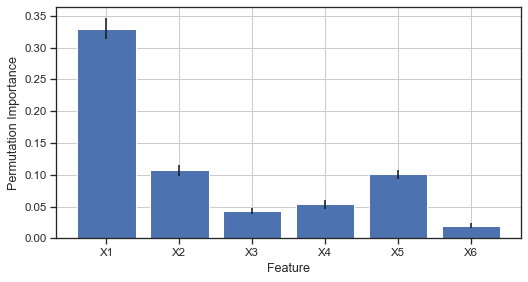

In [20]:
#### Agitar los datos.

importances_bag_class_estim = permutation_importance(bag_class_estim, 
                                    X_train[INPUTS_DT], y_train,
                                    n_repeats=40,
                                    random_state=0)

fig = plt.figure(2, figsize=(8, 4)) 
plt.bar(INPUTS_DT, importances_bag_class_estim.importances_mean, yerr=importances_bag_class_estim.importances_std)
## yerr (y_error) es la línea que aparece encima de cada barra, que indica la desviación estándar de la importancia de la variable.
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.grid()
plt.show()

#### 1.5.3 Plot some trees of the ensemble

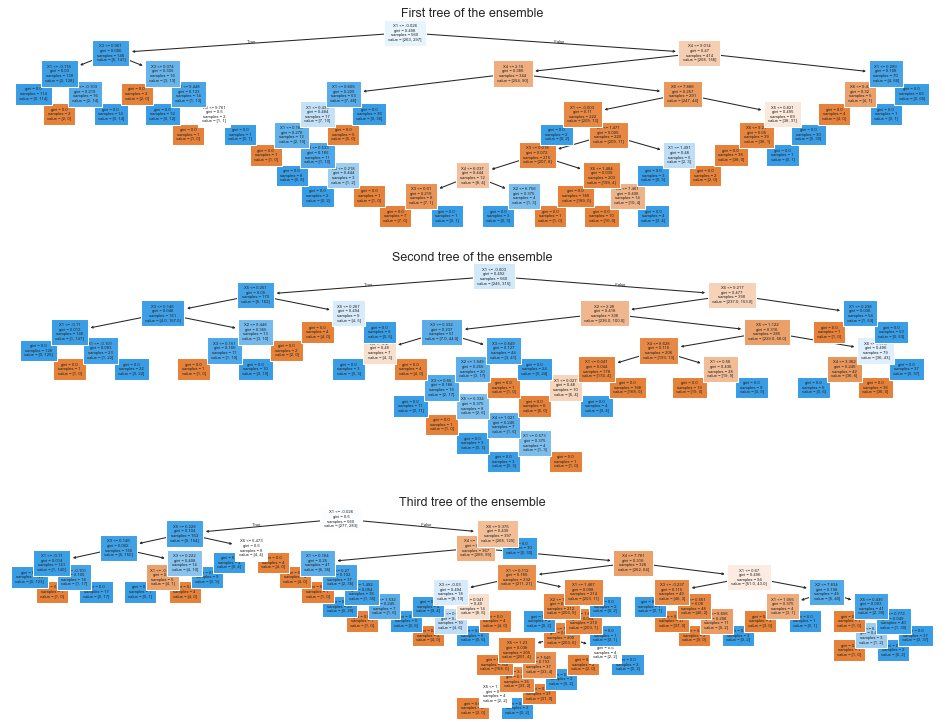

In [21]:
## Plot first trees of the ensemble
plt.figure(figsize=(16, 12))
plt.subplot(3,1,1)
plot_tree(bag_class_estim.estimators_[0]['DT'], feature_names= INPUTS_BT, fontsize=4, filled=True)
plt.title(f'First tree of the ensemble')
plt.subplot(3,1,2)
plot_tree(bag_class_estim.estimators_[1]['DT'], feature_names= INPUTS_BT, fontsize=4, filled=True)
plt.title(f'Second tree of the ensemble')
plt.subplot(3,1,3)
plot_tree(bag_class_estim.estimators_[2]['DT'], feature_names= INPUTS_BT, fontsize=4, filled=True)
plt.title(f'Third tree of the ensemble')
plt.show()

#### 1.5.4 Variability in the ensemble

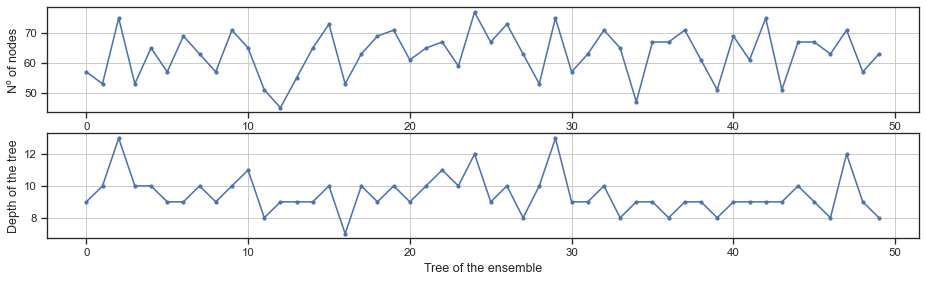

In [22]:
### Número de nodos y profundidad de cada árbol.

# Comparamos el número de nodos y la profundidad de cada uno de los árboles del ensamblado.

# number of nodes in each tree of the ensemble
node_count_trees = [t['DT'].tree_.node_count for t in bag_class_estim.estimators_]

# number of nodes in each tree of the ensemble
depth_trees = [t['DT'].tree_.max_depth for t in bag_class_estim.estimators_]

fig = plt.figure(1, figsize=(15, 4))
ax1=plt.subplot(2,1,1)
plt.plot(node_count_trees, '.-')
plt.ylabel('Nº of nodes')                       
plt.grid()

plt.subplot(2,1,2, sharex = ax1)
plt.plot(depth_trees, '.-')
plt.ylabel('Depth of the tree')                       
plt.xlabel('Tree of the ensemble')                  
plt.grid()
plt.show()

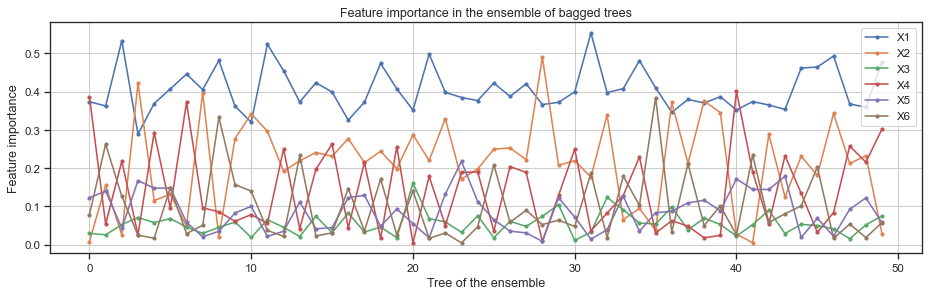

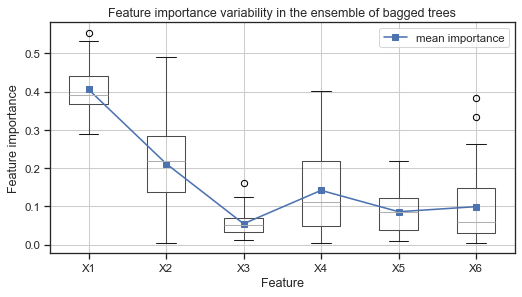

In [23]:
## Importancia de cada variable para cada uno de los árboles.

# feature importances of each tree in the ensemble
feature_importances_trees = [t['DT'].feature_importances_ for t in bag_class_estim.estimators_] 

fig = plt.figure(1, figsize=(15, 4))
plt.plot(feature_importances_trees, '.-', label = INPUTS_BT)
plt.ylabel('Feature importance') 
plt.xlabel('Tree of the ensemble')                                 
plt.title('Feature importance in the ensemble of bagged trees')
plt.grid()
plt.legend()
plt.show()

# global view of feature importances
dfimp =  pd.DataFrame(list(feature_importances_trees), columns=INPUTS_BT)
dfimp.boxplot(figsize=(8, 4))
plt.plot(np.arange(len(INPUTS_BT))+1, dfimp.mean(),'s-', label ='mean importance')
plt.ylabel('Feature importance') 
plt.xlabel('Feature') 
plt.title('Feature importance variability in the ensemble of bagged trees')
plt.legend()
plt.show()

#### 1.5.5 Vote of each tree of the ensemble for each observation in the set

In [25]:
## La columna hace referencia al punto y la fila a la votacion del arbol para cada uno de los puntos.


clf = bag_class_estim
#y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
# Votos de cada uno de los árboles para el conjunto de entrenamiento. (Tenemos 50 árboles)
y_train_pred_trees = list([t['DT'].predict(X_train[INPUTS_DT]) for t in bag_class_estim.estimators_])

dfouts = pd.DataFrame(y_train_pred_trees)
dfouts.head()

#y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()
# Votos de cada uno de los árboles para el conjunto de test. (Tenemos 50 árboles)
y_test_pred_trees = list([t['DT'].predict(X_test[INPUTS_DT]) for t in bag_class_estim.estimators_])

# Votación de cada árbol para cada punto del conjunto de entrenamiento.
dfouts_tr = pd.DataFrame(y_train_pred_trees)
dfouts_tr.head()


# Votación de cada árbol para cada punto del conjunto de test.
dfouts_ts = pd.DataFrame(y_test_pred_trees)
dfouts_ts.head()



/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeC

,0,1,2,3,4,5,6,7,8,9,...,130,131,132,133,134,135,136,137,138,139
0,0,1,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,0,0,0,1
1,0,1,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,1,0,0,1
2,0,1,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,1,0,1,1
3,0,1,1,0,0,0,0,1,1,1,...,0,0,0,1,0,1,1,0,0,1
4,0,1,1,0,0,0,0,1,1,1,...,0,0,0,1,0,0,0,0,0,1


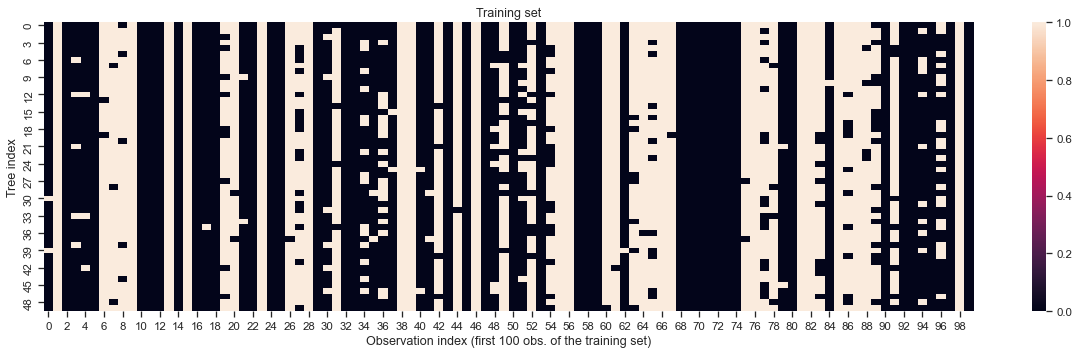

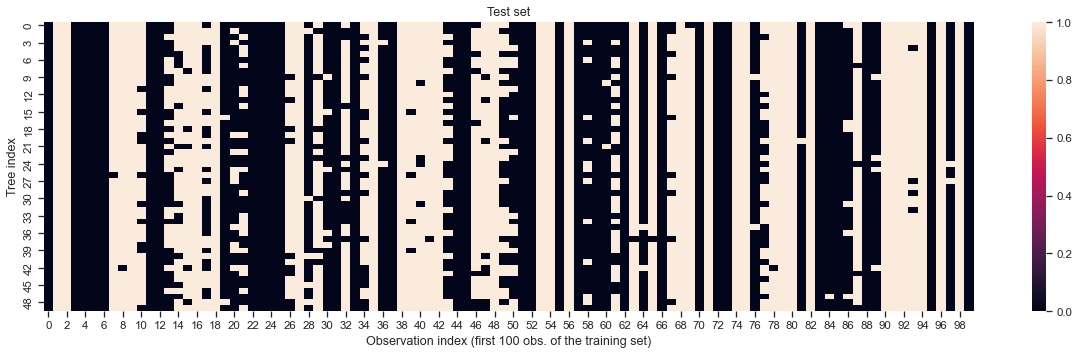

In [26]:
# plot the votes of each tree for the first 100 observations of the training set
fig = plt.figure(figsize=(20, 5))
sns.heatmap(dfouts_tr.iloc[:,:100])
plt.xlabel('Observation index (first 100 obs. of the training set)')
plt.ylabel('Tree index')
plt.title('Training set')                                 
plt.show()

fig = plt.figure(figsize=(20, 5))
sns.heatmap(dfouts_ts.iloc[:,:100])
plt.xlabel('Observation index (first 100 obs. of the training set)')
plt.ylabel('Tree index')
plt.title('Test set')                                 
plt.show()
###### TRAINING
###### Se observa consenso para algunas muestras, como las 68-74.
##### Para algunas muestras, hay árboles que parecen equivocarse. Lo que diferencia a unos árboles de otros es la muestra boostrap. Por lo tanto, hay muestras
##### problemáticas.
##### 

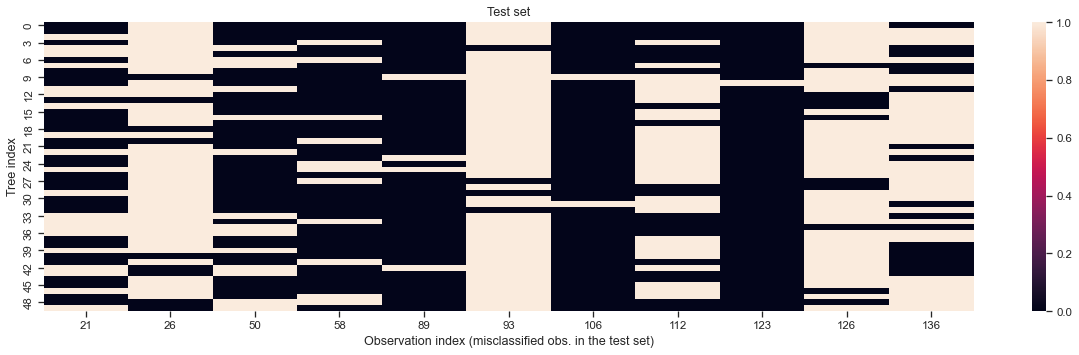

In [28]:
### CASOS EN TEST QUE EL MODELO HA CLASIFICADO MAL.

# focus on the misclassified observations
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
class_errors_tr = [x!=y for x,y in zip(y_train.tolist(), y_train_pred)] # Es una lista boolena que nos dice si la clasificación es correcta o no.

y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()
class_errors_ts = [x!=y for x,y in zip(y_test.tolist(), y_test_pred)] # Es una lista boolena que nos dice si la clasificación es correcta o no.

# plot the votes of each tree for the first 100 observations of the training set
fig = plt.figure(1,figsize=(20, 5))
sns.heatmap(dfouts_ts.iloc[:,class_errors_ts]) # Nos quedamos con las columnas que son errores.
plt.xlabel('Observation index (misclassified obs. in the test set)')
plt.ylabel('Tree index')
plt.title('Test set')                                 
plt.show()

### Vemos dos tipos de situaciones:
### 1.- Algunos índices para los que hay consenso. (para mal)
### 2.- Otros en los que se ha quedado a la mitad y finalmente se han decantado por la opción incorrecta.

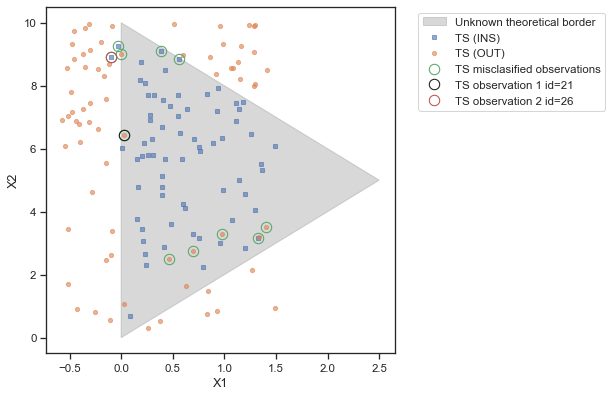

In [29]:
# plot some misclassified observations

id_obs_1 = 21 # a particular obs (no clear consensus) 
id_obs_2 = 26 # a particular obs (almost full agreement)

fig = plt.figure(figsize=(6, 6))

plt.fill([0, 0, 2.5], [0, 10, 5], color='gray', alpha=0.3, label ='Unknown theoretical border')

plt.plot(X_test.loc[y_test == 'INS', 'X1'], X_test.loc[y_test == 'INS', 'X2'], 's', alpha=0.6,
         markersize = 4, label = 'TS (INS)')
plt.plot(X_test.loc[y_test == 'OUT', 'X1'], X_test.loc[y_test == 'OUT', 'X2'],'o', alpha=0.6,
         markersize = 4, label = 'TS (OUT)')

plt.plot(X_test.loc[class_errors_ts,'X1'], X_test.loc[class_errors_ts,'X2'],'og', 
         markersize = 10, fillstyle = 'none', label = 'TS misclasified observations')
plt.plot(X_test.iloc[id_obs_1, 0], X_test.iloc[id_obs_1, 1],'ok', markersize = 10, 
         fillstyle = 'none', label = f'TS observation 1 id={id_obs_1}')
plt.plot(X_test.iloc[id_obs_2, 0], X_test.iloc[id_obs_2, 1],'or', markersize = 10, 
         fillstyle = 'none', label = f'TS observation 2 id={id_obs_2}')

plt.ylabel('X2')
plt.xlabel('X1')    
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0))                   
plt.show()

##### El triángulo gris es la frontera que se ha usado para clasificar las observaciones.
##### Los mal clasificados que están en la frontera no deberían preocuparnos.
##### Nos deberían preocupar los que están dentro rodeados, ya que esos se estan clasificando mal y estan lejos de la frontera. Deberíamos convertirlos en azules.
##### Podría deberse a datos que están mal.

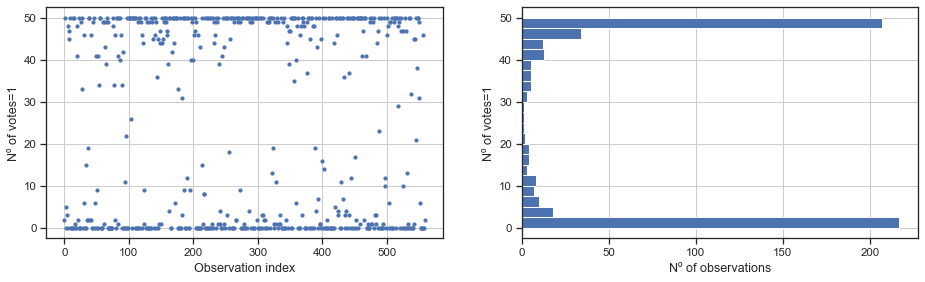

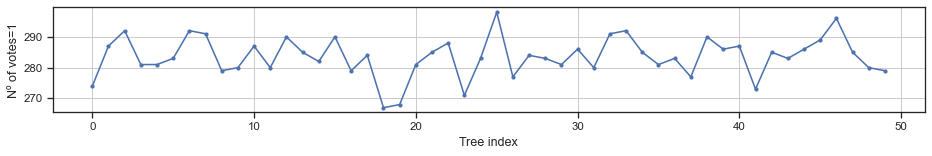

In [32]:

##### Hacemos esta gráfica para ver la confianza con la que clasifica en cada cosa. 
##### No hay una preferencia hacia decir dentro o decir fuera. 

# dfouts es un df donde cada fila representa un árbol y cada columna representa una observación.
# Número total de árboles que han votado 1 para cada observación.
n_1s_each_obs = dfouts.sum(axis=0)

# n_1s_each_tree almacena el número total de veces que cada árbol ha votado 1 a lo largo de todas las observaciones.
n_1s_each_tree = dfouts.sum(axis=1)

# plot
fig = plt.figure(figsize=(15, 4))
ax1=plt.subplot(1,2,1)
plt.plot(n_1s_each_obs, '.')
plt.ylabel('Nº of votes=1')
plt.xlabel('Observation index')                       
plt.grid()

plt.subplot(1,2,2,sharey=ax1)
plt.hist(n_1s_each_obs,bins=20,orientation='horizontal')
plt.ylabel('Nº of votes=1')
plt.xlabel('Nº of observations')
plt.grid()
plt.show()

fig = plt.figure(figsize=(15, 4))
plt.subplot(2,1,2)
plt.plot(n_1s_each_tree, '.-')
plt.ylabel('Nº of votes=1')                       
plt.xlabel('Tree index')                  
plt.grid()
plt.show()

### 1º grafico: Número de árboles que han votado 1 para cada observación.
### El modelo no tiene una tendencia clara a clasificar en una dirección u otra.

### 2º grafico: Distribución del número de votos de los árboles.
###  Si la distribución es simétrica, significa que las observaciones son clasificadas con diferentes niveles de certeza.
###  Si hay acumulaciones en los extremos (muchas observaciones con votos cercanos a 0 o al máximo), significa que el modelo tiende a clasificar de manera clara la mayoría de los casos.

### En el de abajo podemos ver que arboles son más propensos a votar sí o no, cuales tienen un sesgo hacia votar si o no.

### 1.6 Fit optimal classification bagged tree using Grid Search

In [30]:
## Buscamos el mejor número de árboles en el ensamblado, y ajustamos el mejor.

# find optim nº of trees in the ensemble
param = {'BT__n_estimators': range(20, 150, 5)} # Number of trees to aggregate

pipe =  Pipeline(steps=[('BT', 
                            BaggingClassifier(estimator=base_estimator,
                                              random_state=150))])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
bt_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds, # Number of Folds 
                       refit=True) # (default) the best model is finally refitted using the whole training set **
# fit the bagged trees
INPUTS_BT = INPUTS  
bt_fit.fit(X_train[INPUTS_BT], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('BT',
                                        BaggingClassifier(estimator=Pipeline(steps=[('DT',
                                                                                     DecisionTreeClassifier(random_state=999))]),
                                                          random_state=150))]),
             n_jobs=-1, param_grid={'BT__n_estimators': range(20, 150, 5)},
             scoring='accuracy')

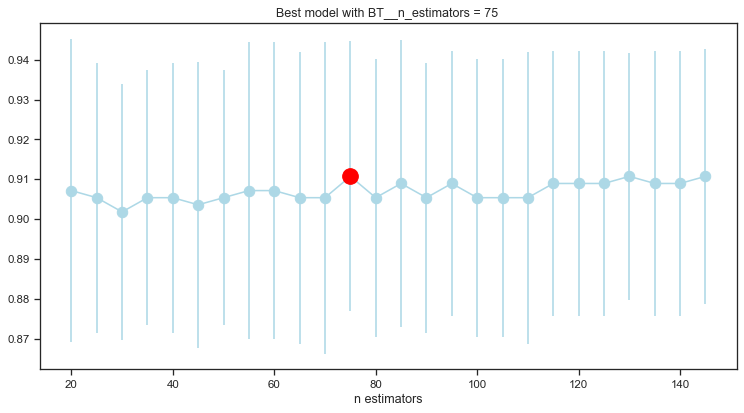

In [31]:
uml1.plotModelGridError(bt_fit)

In [32]:
# model predictions in training (TR) and test (TS) sets
clf = bt_fit.best_estimator_['BT']
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()

# main metrics
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                    TR        TS
Accuracy           1.0  0.907143
Balanced accuracy  1.0  0.907226

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  275    0
      OUT    0  285

Accuracy: 1.0
No Information Rate: 0.5
Kappa: 1.0
Mcnemar's Test P-Value: 1.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0
Recall: 1.0
Prevalence: 0.51
Detection Rate: 0.51
Detection prevalence: 0.51
Balanced accuracy: 1.0
F1 Score: 1.0
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   63    6
      OUT    7   64

Accuracy: 0.91
No Information Rate: 0.5
Kappa: 0.81
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.9
Specificity: 0.91
Precision: 0.9
Recall: 0.91
Prevalence: 0.51
Detection Rate: 0.46
Detection prevalence: 0.5
Balanced accuracy: 0.91
F1 Score: 0.91
Positive label: INS


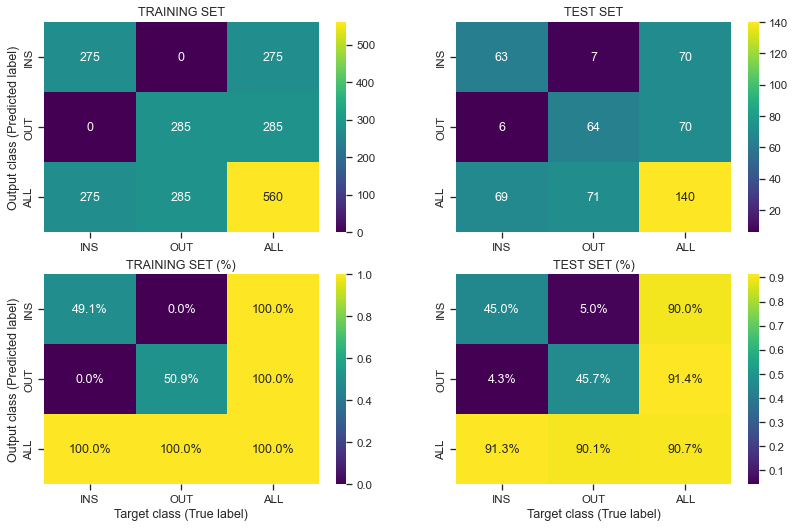

In [33]:
ucml2.plot_expanded_confusion_matrix(clf, X_train, y_train, X_test, y_test)

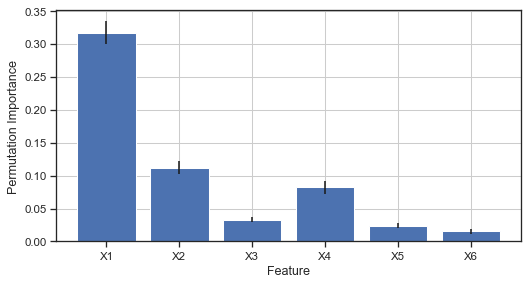

In [34]:
importances_bag_class_estim = permutation_importance(bt_fit, 
                                    X_train[INPUTS_DT], y_train,
                                    n_repeats=40,
                                    random_state=0)

fig = plt.figure(2, figsize=(8, 4)) 
plt.bar(INPUTS_DT, importances_bag_class_estim.importances_mean, yerr=importances_bag_class_estim.importances_std)
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.grid()
plt.show()